# Лабораторная работа №4: Линейная регрессия

Автор: Федорова Софья Александровна, 6401-010302D

Датасет Student Performance Factors Dataset  содержит данные о количестве учебных часов, посещаемости, уровне мотивации, доступности учебных ресурсов, участии родителей, качестве учителей, влиянии сверстников и семейного происхождение. Также включены элементы окружающей среды и образа жизни, включая доступность интернета, режим сна и тип школы. Набор данных можно использовать для прогнозирования результатов и получения образовательных инсайтов, поскольку целевой переменный отражает результаты экзаменов учеников. Вместе эти характеристики создают комплексный набор данных, который можно использовать для анализа различных факторов, влияющих на академические достижения.

Ссылка на датасет: https://www.kaggle.com/datasets/ayeshasiddiqa123/student-perfirmance?resource=download

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import scipy.stats
import  plotly

## 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

### Считывание датасета из csv-файла

In [2]:
file = 'StudentPerformanceFactors.csv'

df = pd.read_csv(file)

## 2.  Датасет и подготовка данных, этап 1:

#### Привести описание датасета.

 Датасет содержит данные об академических, поведенческих, семейных и школьных факторах, влияющих на результаты экзаменов (Exam_Score), которые являются целевым признаком.
  
   | Признак | Тип признака | Описание | Единицы измерения |   
   | --- | --- | --- | --- | 
   | Hours_Studied | quantitative | Количество часов, которые студент тратит на учебу еженедельно | hours 
   | Attendance | quantitative | Процент посещаемости занятий студентом | percents 
   | Parental_Involvement | categorical | Академическая поддержка родителей | 
   | Access_to_Resources | categorical | Доступность учебных ресурсов | 
   | Extracurricular_Activities | categorical | Участие во внеурочной деятельности | 
   | Sleep_Hours  | quantitative | Средняя продолжительность сна в сутки | hours
   | Previous_Scores | quantitative | Прошлые академические результаты | score
   | Motivation_Level | categorical | Уровень мотивации студента | 
   | Internet_Access | categorical | Статус доступности интернета | 
   | Tutoring_Sessions | quantitative | Дополнительные занятия с репетитором | hours
   | Family_Income | categorical  | Семейный доход (уровень класса) |
   | Teacher_Quality | categorical | Уровень квалификации преподавателя |
   | School_Type | categorical | Тип учебного заведения | 
   | Peer_Influence | categorical | Влияние сверстников |
   | Physical_Activity  | quantitative | Количество часов для физической активности, которые студент выделяет еженедельно| hours
   | Learning_Disabilities | categorical | Столкновение с трудностями в процессе обучения |
   | Parental_Education_Level | categorical | Уровень образования родителей |
   | Distance_from_Home | categorical | Расстояние до учебного заведения от дома студента |
   | Gender | categorical | Пол | 
   | **Exam_Score** | **quantitative** | **Результаты экзаменов (целевая переменная)** | **score**



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

#### Осуществить предобработку данных (избавиться от null, убрать некоторые признаки и т.п.) – "подчистить данные".

In [4]:
df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6378 non-null   int64 
 1   Attendance                  6378 non-null   int64 
 2   Parental_Involvement        6378 non-null   object
 3   Access_to_Resources         6378 non-null   object
 4   Extracurricular_Activities  6378 non-null   object
 5   Sleep_Hours                 6378 non-null   int64 
 6   Previous_Scores             6378 non-null   int64 
 7   Motivation_Level            6378 non-null   object
 8   Internet_Access             6378 non-null   object
 9   Tutoring_Sessions           6378 non-null   int64 
 10  Family_Income               6378 non-null   object
 11  Teacher_Quality             6378 non-null   object
 12  School_Type                 6378 non-null   object
 13  Peer_Influence              6378 non-null   object
 1

#### Нормализовать численные данные.

In [6]:
num_columns = df.describe().columns.tolist()

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

df[num_columns] = scaler.fit_transform(df[num_columns])

In [8]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6.378000e+03,6.378000e+03,6.378000e+03,6.378000e+03,6.378000e+03,6.378000e+03,6.378000e+03
mean,-1.693360e-16,5.458858e-16,-1.030499e-16,4.634459e-16,1.002647e-17,8.021179e-17,-6.617472e-16
std,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00
min,-3.170784e+00,-1.733435e+00,-2.067530e+00,-1.740795e+00,-1.211858e+00,-2.889375e+00,-3.130404e+00
25%,-6.645138e-01,-8.676200e-01,-7.050558e-01,-8.379712e-01,-4.014114e-01,-9.454473e-01,-5.754136e-01
50%,3.824766e-03,-1.805477e-03,-2.381873e-02,-4.595024e-03,-4.014114e-01,2.651641e-02,-6.441555e-02
75%,6.721634e-01,8.640091e-01,6.574183e-01,8.982292e-01,4.090356e-01,9.984802e-01,4.465824e-01
max,4.013856e+00,1.729824e+00,2.019892e+00,1.731605e+00,5.271718e+00,2.942408e+00,8.622550e+00


#### Визуализировать heatmap-матрицу коррелированности признаков.

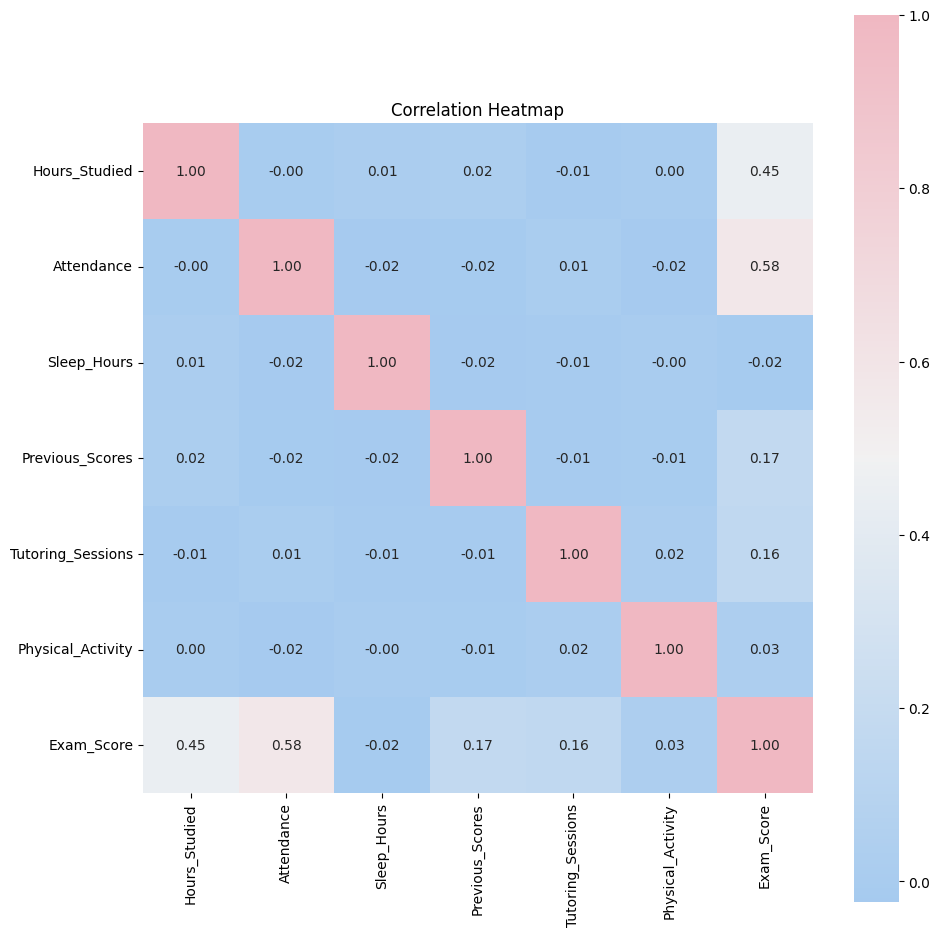

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df[num_columns]
fig, ax = plt.subplots(figsize=(10, 10))
plt.title('Correlation Heatmap')
cmap = sns.diverging_palette(240, 0, s=70, l=80, as_cmap=True)
ax_sns = sns.heatmap(ax = ax, data=data.corr(), cmap=cmap, square=True, annot=True, fmt='.2f', linecolor='white')
ax_sns.set_yticklabels(ax_sns.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.15)
fig.tight_layout()
plt.show()

Между целевым признаком (`Exam_Score`) и такими параметрами, как `Hourd_Studies`, `Attendence`, `Previous_Score`, `Tutoring_Sessions` существуюет явная корреляция.

#### Визуализировать взаимосвязь между target-переменной и каждым из признаков (с использованием `srs.pairplot` или `pandas.plotting.scatter_matrix`).

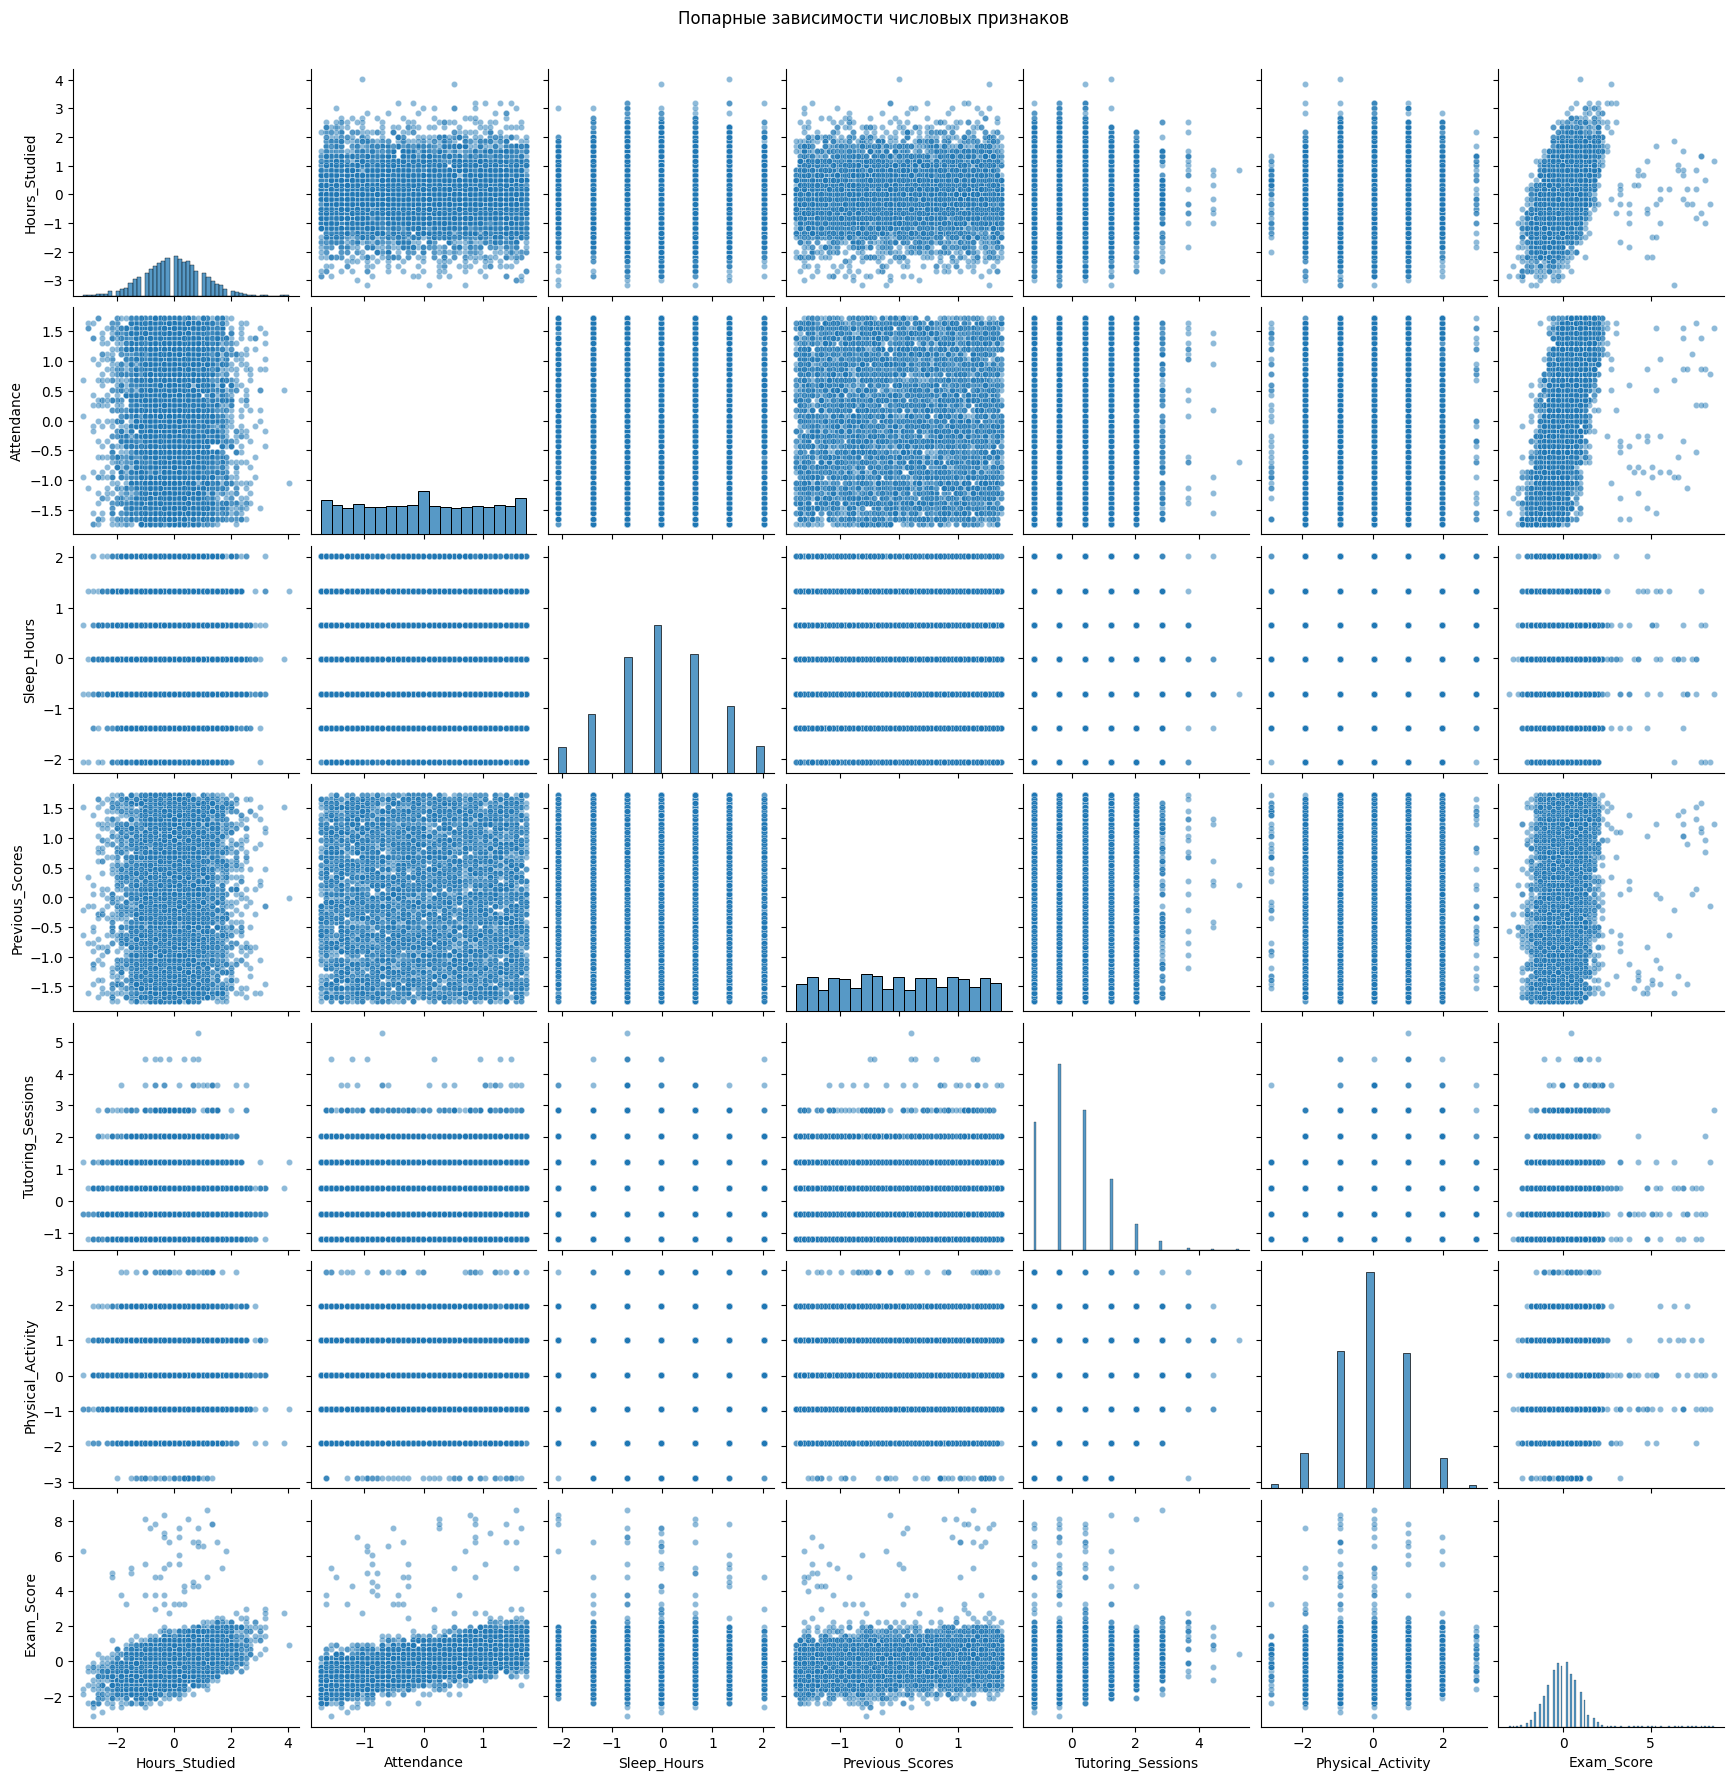

In [10]:
import seaborn as sns
df_numeric = df[num_columns]

g = sns.pairplot(data=df_numeric, diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
fig_sns = g.figure
fig_sns.suptitle('Попарные зависимости числовых признаков', y=1.02)
plt.show()

#### Лучше всего построить диаграмму попарного распределения между таргетом и каждым из признаков отдельно (пример с `sns.FacetGrid` в лекции).

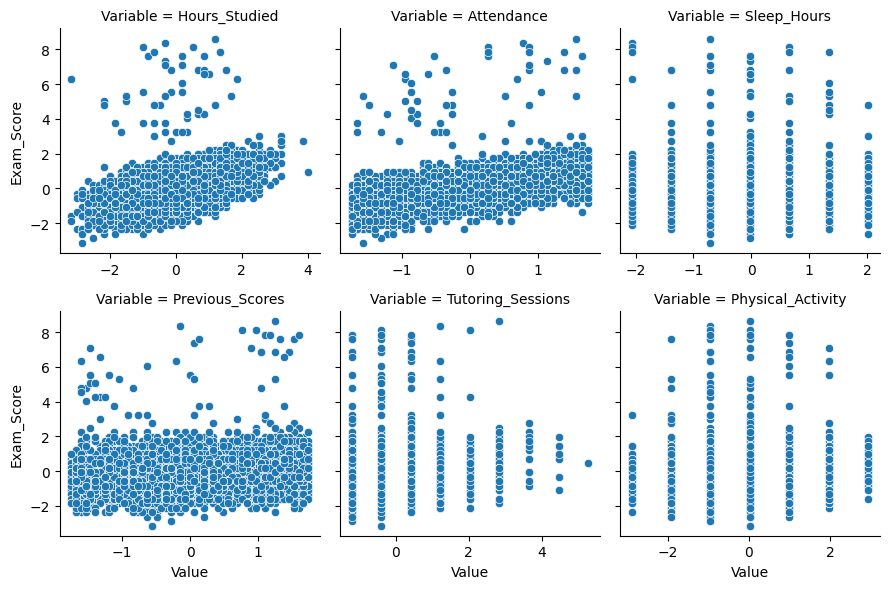

In [11]:
target = 'Exam_Score'
columns_to_plot = df_numeric.drop(columns=target)

df_melted = df_numeric.melt(id_vars=[target], 
                            value_vars=columns_to_plot.columns,
                            var_name='Variable', 
                            value_name='Value')

g = sns.FacetGrid(df_melted, col='Variable', col_wrap=3, sharex=False)
g.map_dataframe(sns.scatterplot, x='Value', y=target)
g.tight_layout()

#### Разбить выборку на обучающую и тестовую.


На данном этапе существует датасет  `df`, который содержит нормализованные количественные данные и категориальные признаки.

При разбиении данных на тестовые и тренировочные выборки оказалось, что существует проблема в данных `The least populated class in y has only 1 member, which is too few.`. Найдем эти данные и почистим датасет.

In [12]:
columns_list = df.columns.tolist()

In [13]:
rare_values = {} # хранятся редковстречающиеся значения

for col in columns_list:
    value_counts = df[col].value_counts()
    rare = value_counts[value_counts < 4].index.tolist()
    
    if rare:
        rare_values[col] = rare
        df = df[~df[col].isin(rare)]


In [14]:
y = df[target]
X = df.drop(columns=target)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.75, random_state=42
)

 - Из датафреймов обучающей и тестовой выборки необходимо временно убрать категориальные признаки (исходные датафреймы сохранить для 2 этапа).

In [16]:
quantitative_columns = ['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity']

In [17]:
X_train_quantitative = X_train[quantitative_columns]
X_test_quantitative = X_test[quantitative_columns]

### 3. Регрессия МНК

Обучить модель линейной регрессии `LinearRegression`.

In [18]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()

regr.fit(X_train_quantitative, y_train);

Вывести метрики `MSE`, `MAE` и `R**2` на тестовом наборе.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"MSE: {mse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f} \n")
    return mse, mae, r2

y_preds = {}
y_pred_linear_reg = regr.predict(X_test_quantitative) 
y_preds['y_pred_linear_reg'] = y_pred_linear_reg

print("Linear Regression Metrics:")
metrics = evaluate_model(y_test, y_pred_linear_reg)

Linear Regression Metrics:
MSE: 0.20, MAE: 0.30, R²: 0.75 



Вывести `model.coef_` и `model.intercept_`.

In [20]:
print(f'Coefficients: {regr.coef_} ')
print(f'Intercept : {regr.intercept_} ')

Coefficients: [ 0.45090173  0.5840699  -0.00676817  0.1810159   0.15284291  0.03595954] 
Intercept : -0.02954509094391549 


Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).

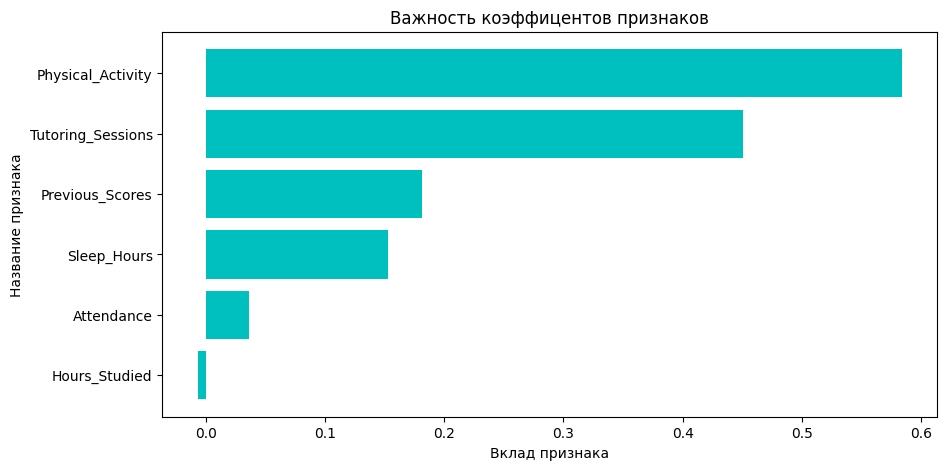

In [21]:
fig = plt.figure(figsize=(10, 5))

plt.barh(X_test_quantitative.columns, sorted(regr.coef_), color="c")

plt.xlabel("Вклад признака")
plt.ylabel("Название признака")
plt.title("Важность коэффицентов признаков")
plt.show()

### 4. Для каждого вида регрессии (`Ridge`, `LASSO`, `Elastic Net`, `KNeighborsRegressor` и какой-нибудь `tree-based модели регрессии`):

С использованием `GridSearchCV` осуществить подбор параметров регуляризации (`alpha` для Ridge и LASSO, `alpha` и `l1_ratio` для Elastic Net) и гиперпараметров (`n_neighbors` для KNeighborsRegressor; как минимум `max_depth` для tree-based моделей регрессии).

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

models = {
    "Ridge": (Ridge(), {'alpha': [0.01, 0.1, 1, 10]}),
    "Lasso": (Lasso(), {'alpha': [0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(), {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.7]}),
    "KNeighborsRegressor": (KNeighborsRegressor(), {'n_neighbors': range(1, 16)}),
    "DecisionTreeRegressor": (DecisionTreeRegressor(), {'max_depth': range(1, 6), 'max_features': range(2, 6)}) #ограничили количеством признаков
}

best_models = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, scoring='neg_mean_squared_error', cv=5)
    grid.fit(X_train_quantitative, y_train)
    best_model = grid.best_estimator_
    y_preds[f'y_pred_{model}'] = best_model.predict(X_test_quantitative)

    print(f"\n{name} -> Best Params: {grid.best_params_}")

    if isinstance(model, (Ridge, Lasso, ElasticNet)):
        print(f"Coefficients shape: {best_model.coef_}")
        print(f"Intercept: {best_model.intercept_}")
        best_models[name] = [best_model, best_model.coef_, best_model.intercept_]
        continue
    
    best_models[name] = best_model



Ridge -> Best Params: {'alpha': 1}
Coefficients shape: [ 0.45080397  0.58394403 -0.00677069  0.18097737  0.15280896  0.0359491 ]
Intercept: -0.029545733567381754

Lasso -> Best Params: {'alpha': 0.01}
Coefficients shape: [ 0.44052331  0.5736796  -0.          0.1711796   0.14279108  0.02578137]
Intercept: -0.02955807364186327

ElasticNet -> Best Params: {'alpha': 0.01, 'l1_ratio': 0.1}
Coefficients shape: [ 0.44572963  0.57771517 -0.00593217  0.17841475  0.15041039  0.03451186]
Intercept: -0.02957248704489281

KNeighborsRegressor -> Best Params: {'n_neighbors': 15}

DecisionTreeRegressor -> Best Params: {'max_depth': 5, 'max_features': 5}


Вывести значения гиперпараметров, коэффициенты регрессии (`model.coef_` и `model.intercept_`) и значения метрик на тестовом наборе для наилучшей модели (`MSE`, `MAE` и `R**2`).

In [23]:
df_metrics = pd.DataFrame(columns=['model', 'MSE', 'MAE', 'R_2'])

for i, (name, params) in enumerate(best_models.items()):
    if isinstance(params, list):
        model = params[0]
        print(f'{model}')
        print(f'{name}.coef_ = {params[1]}')
        print(f'{name}.intercept_ = {params[2]}')
    else:
        model = params
        print(f'{model}')
    model.fit(X_train_quantitative, y_train)
    y_model = model.predict(X_test_quantitative)
    mse, mae, r_2 = evaluate_model(y_test, y_model)
    df_metrics.loc[i] = [model, mse, mae, r_2]


Ridge(alpha=1)
Ridge.coef_ = [ 0.45080397  0.58394403 -0.00677069  0.18097737  0.15280896  0.0359491 ]
Ridge.intercept_ = -0.029545733567381754
MSE: 0.20, MAE: 0.30, R²: 0.75 

Lasso(alpha=0.01)
Lasso.coef_ = [ 0.44052331  0.5736796  -0.          0.1711796   0.14279108  0.02578137]
Lasso.intercept_ = -0.02955807364186327
MSE: 0.20, MAE: 0.30, R²: 0.75 

ElasticNet(alpha=0.01, l1_ratio=0.1)
ElasticNet.coef_ = [ 0.44572963  0.57771517 -0.00593217  0.17841475  0.15041039  0.03451186]
ElasticNet.intercept_ = -0.02957248704489281
MSE: 0.19, MAE: 0.30, R²: 0.75 

KNeighborsRegressor(n_neighbors=15)
MSE: 0.23, MAE: 0.34, R²: 0.71 

DecisionTreeRegressor(max_depth=5, max_features=5)
MSE: 0.27, MAE: 0.38, R²: 0.65 



Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).

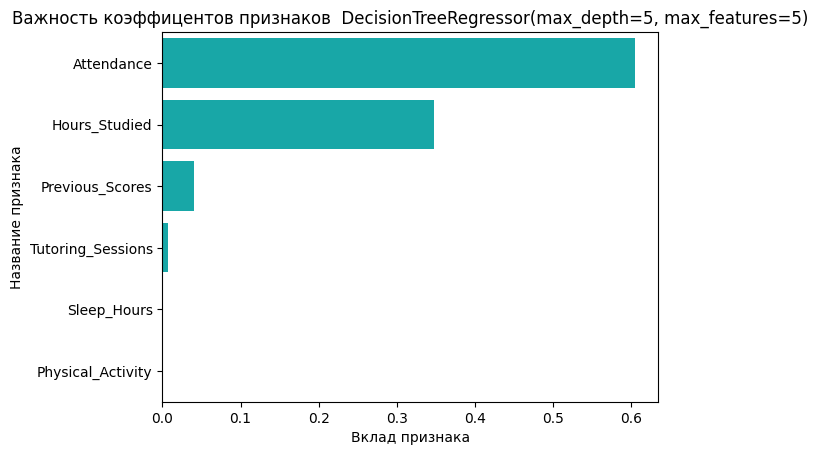

In [24]:
for name, params in best_models.items():
    model = params
    if isinstance(model,(Ridge, Lasso, ElasticNet)):
        coeff_df = pd.DataFrame({
            'Feature': X_train_quantitative.columns, 
            'Coefficient': model.coef_
        })
        coeff_df.sort_values(by='Coefficient', key=abs, ascending=False, inplace=True)
        fig = plt.figure(figsize=(8, 5))

        plt.barh(X_test_quantitative.columns, sorted(regr.coef_), color="c")
        plt.xlabel("Вклад признака")
        plt.ylabel("Название признака")
        plt.title(f"Важность коэффицентов признаков {model}")
        plt.show()

    elif isinstance(model, DecisionTreeRegressor):
        feature_importance_df = pd.DataFrame({
            'Feature': X_train_quantitative.columns, 
            'Importance': model.feature_importances_
        })
        feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
        
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color='c')
        plt.xlabel("Вклад признака")
        plt.ylabel("Название признака")
        plt.title(f"Важность коэффицентов признаков  {model}")
        plt.show()
    

In [25]:
df_metrics

,model,MSE,MAE,R_2
0,Ridge(alpha=1),0.195153,0.299526,0.749763
1,Lasso(alpha=0.01),0.195128,0.299725,0.749794
2,"ElasticNet(alpha=0.01, l1_ratio=0.1)",0.194984,0.299477,0.749979
3,KNeighborsRegressor(n_neighbors=15),0.229927,0.336633,0.705172
4,"DecisionTreeRegressor(max_depth=5, max_feature...",0.274796,0.381833,0.647639


In [26]:
def style_dataframe(df_metrics):
    styled_df = df_metrics.copy()
    numeric_columns = styled_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # Для метрик, где меньшее значение лучше (MSE, MAE, RMSE) используем reverse=True
    # Для R2, где большее значение лучше, reverse=False
    styler = styled_df.style
    
    for col in numeric_columns:
        if col in ['MSE', 'MAE']:  
            styler = styler.background_gradient(cmap='RdYlGn_r', subset=[col], axis=0)
        else:
            styler = styler.background_gradient(cmap='RdYlGn', subset=[col], axis=0)
    
    return styler


In [27]:
style_dataframe(df_metrics)

,model,MSE,MAE,R_2
0,Ridge(alpha=1),0.195153,0.299526,0.749763
1,Lasso(alpha=0.01),0.195128,0.299725,0.749794
2,"ElasticNet(alpha=0.01, l1_ratio=0.1)",0.194984,0.299477,0.749979
3,KNeighborsRegressor(n_neighbors=15),0.229927,0.336633,0.705172
4,"DecisionTreeRegressor(max_depth=5, max_features=5)",0.274796,0.381833,0.647639


Запомнить лучшие модели для 2 этапа: лучшими моделями являются `Ridge` и `Lasso`.



### 5. Датасет и подготовка данных, этап 2:

Использовать датафреймы после разбиения на обучающую и тестовую выборки из 1 этапа с категориальными признаками.

In [28]:
X_test.columns #X_train также

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender'],
      dtype='object')

Закодировать категориальные признаки в обучающей и тестовой выборках.

In [29]:
categorical_columns = X_test.drop(columns=quantitative_columns).columns

Т.к. все категориальные признаки содержат от 2 до 3 уникальных значений, то для кодирования признаков будем использовать  модель `One-Hot Encoding`.

In [30]:
X_test_encoded = X_test.copy()

X_test_encoded = pd.get_dummies(X_test_encoded, columns=categorical_columns, drop_first=True)

In [31]:
X_train_encoded = X_train.copy()

X_train_encoded = pd.get_dummies(X_train_encoded, columns=categorical_columns, drop_first=True)

## 6. Регрессии, этап 2:

Обучить `LinearRegression`, лучшие модели `Ridge`, `LASSO`, `Elastic Net`, `KNeighborsRegressor`, `DecisionTreeRegressor` на обучающем наборе с категориальными признаками.



In [32]:
y_encoded_preds = {}

In [33]:
regr = LinearRegression()
regr.fit(X_train_encoded, y_train)

y_encoded_preds['y_pred_linear_reg'] = regr.predict(X_test_encoded)

In [34]:
for i, (name, params) in enumerate(best_models.items()):
    if isinstance(params, list):
        model = params[0]
    else:
        model = params
    model.fit(X_train_encoded, y_train)
    y_encoded_preds[f'y_pred_{name}'] = model.predict(X_test_encoded)

y_encoded_preds


{'y_pred_linear_reg': array([-1.42507964, -0.30122048,  0.95728273, ..., -1.04339021,
        -0.35174518,  0.75776175]),
 'y_pred_Ridge': array([-1.4248177 , -0.30239234,  0.95637617, ..., -1.04291195,
        -0.35152539,  0.75810516]),
 'y_pred_Lasso': array([-1.46400313, -0.44687881,  0.85396798, ..., -0.98313381,
        -0.3053406 ,  0.8687259 ]),
 'y_pred_ElasticNet': array([-1.41583554, -0.36329079,  0.91043008, ..., -1.02001768,
        -0.33658223,  0.78269463]),
 'y_pred_KNeighborsRegressor': array([-1.05234502, -0.71167969,  0.65098165, ..., -0.38804762,
        -0.30288129,  0.56581531]),
 'y_pred_DecisionTreeRegressor': array([-0.72824981, -0.72824981, -0.17031316, ..., -0.51235422,
         0.46290081,  0.44496537])}

Вывести значения гиперпараметров, коэффициенты регрессии (`model.coef_` и `model.intercept_`) и значения метрик на тестовом наборе для наилучшей модели (`MSE`, `MAE` и `R**2`).

In [35]:
df_categorical_metrics = pd.DataFrame(columns=['model', 'MSE', 'MAE', 'R_2'])

best_models_encoded = {}

for i, (name, params) in enumerate(best_models.items()):
    if isinstance(params, list):
        model = params[0]
        print(f'{model}')
        print(f'{name}.coef_ = {params[1]}')
        print(f'{name}.intercept_ = {params[2]}')
    else:
        model = params
        print(f'{model}')
    model.fit(X_train_encoded, y_train)
    y_model = model.predict(X_test_encoded)
    if isinstance(params, list):
        best_models_encoded[name] = [model, model.coef_, model.intercept_]
    else:
        best_models_encoded[name] = model

    mse, mae, r_2 = evaluate_model(y_test, y_model)
    df_categorical_metrics.loc[i] = [model, mse, mae, r_2]



Ridge(alpha=1)
Ridge.coef_ = [ 0.45080397  0.58394403 -0.00677069  0.18097737  0.15280896  0.0359491 ]
Ridge.intercept_ = -0.029545733567381754
MSE: 0.07, MAE: 0.08, R²: 0.91 

Lasso(alpha=0.01)
Lasso.coef_ = [ 0.44052331  0.5736796  -0.          0.1711796   0.14279108  0.02578137]
Lasso.intercept_ = -0.02955807364186327
MSE: 0.09, MAE: 0.14, R²: 0.88 

ElasticNet(alpha=0.01, l1_ratio=0.1)
ElasticNet.coef_ = [ 0.44572963  0.57771517 -0.00593217  0.17841475  0.15041039  0.03451186]
ElasticNet.intercept_ = -0.02957248704489281
MSE: 0.07, MAE: 0.09, R²: 0.90 

KNeighborsRegressor(n_neighbors=15)
MSE: 0.21, MAE: 0.31, R²: 0.74 

DecisionTreeRegressor(max_depth=5, max_features=5)
MSE: 0.36, MAE: 0.45, R²: 0.53 



Сравнить метрики с наличием категориальных признаков и без для каждой из моделей.

In [36]:
style_dataframe(df_metrics)

,model,MSE,MAE,R_2
0,Ridge(alpha=1),0.195153,0.299526,0.749763
1,Lasso(alpha=0.01),0.195128,0.299725,0.749794
2,"ElasticNet(alpha=0.01, l1_ratio=0.1)",0.194984,0.299477,0.749979
3,KNeighborsRegressor(n_neighbors=15),0.229927,0.336633,0.705172
4,"DecisionTreeRegressor(max_depth=5, max_features=5)",0.274796,0.381833,0.647639


In [37]:
style_dataframe(df_categorical_metrics)

,model,MSE,MAE,R_2
0,Ridge(alpha=1),0.072607,0.083439,0.906899
1,Lasso(alpha=0.01),0.093554,0.144073,0.880040
2,"ElasticNet(alpha=0.01, l1_ratio=0.1)",0.074979,0.092385,0.903857
3,KNeighborsRegressor(n_neighbors=15),0.205670,0.310223,0.736276
4,"DecisionTreeRegressor(max_depth=5, max_features=5)",0.364357,0.445467,0.532798


С добавлением категориальных признаков метрики для `MSE`, `MAE` для моделей класса линейныйх регрессий снизились минимум вдвое (наилучшее изменение - в 3 раза). Показатель метрики для `R**2` наоборот увеличился, тем самым отразив качество модели (целевое значение для этой метрики 1, а наилучшее найденное значение ~ 0.91).

Показатели для модели `k-ближайших соседей` тоже улучшились, но не на много (~0.02 от данных без категориальных признаков). Это говорит о том, что категориальные признаки не вносят большой вклад для формирования прогноза моделью.

Метрики для модели `DecisionTreeRegressor` показали наихудшие результаты сразу для двух эксперементов. Это связано с тем, что деревья склонны к переобучению при большом наборе признаков (размерность изменилась с 6 до 27 признаков).

Выбрать лучшую модель.

Т.к. мы очениваем метрики по-разному, для MSE, MAE, RMSE лучшим значением является наименьшая величина, в то время как для R2 лучшее значение - большее, то лучшей моделью является гребневая регрессия (`Ridge Regression`).


Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).

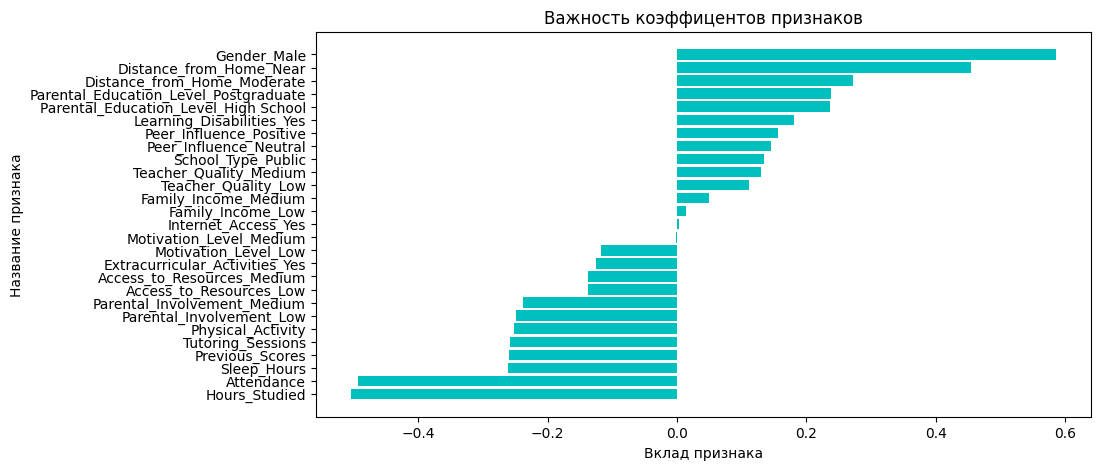

In [38]:
fig = plt.figure(figsize=(10, 5))
coef = best_models_encoded['Ridge'][1]

plt.barh(X_test_encoded.columns, sorted(coef), color="c")

plt.xlabel("Вклад признака")
plt.ylabel("Название признака")
plt.title("Важность коэффицентов признаков")
plt.show()

Осуществить фильтрацию признаков:
- с использованием `Recursive Feature Elimination` или [RFECV](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html) (`RFE` с кросс-валидацией)

Оптимальное количество признаков: 25
Лучший R²: 0.905

Выбранные признаки (25):
['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'School_Type_Public', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']


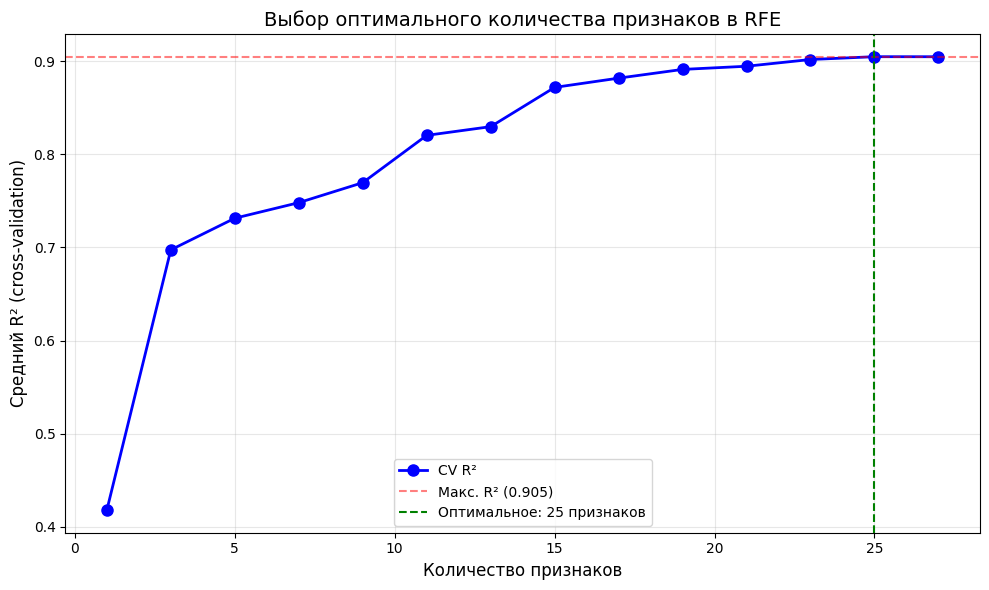

In [39]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

n_features_range = range(1, X_train_encoded.shape[1] + 1, 2)  
cv_scores = []

for n in n_features_range:
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    scores = cross_val_score(rfe, X_train_encoded, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())


optimal_idx = np.argmax(cv_scores)  
optimal_n_rfe = n_features_range[optimal_idx]

print(f"Оптимальное количество признаков: {optimal_n_rfe}")
print(f"Лучший R²: {cv_scores[optimal_idx]:.3f}")

rfe_final = RFE(estimator=LinearRegression(), n_features_to_select=optimal_n_rfe)
rfe_final.fit(X_train_encoded, y_train)

selected_mask = rfe_final.support_
selected_features = X_train_encoded.columns[selected_mask]
print(f"\nВыбранные признаки ({len(selected_features)}):")
print(selected_features.tolist())

plt.figure(figsize=(10, 6))
plt.plot(n_features_range, cv_scores, 'bo-', linewidth=2, markersize=8, label='CV R²')
plt.axhline(y=max(cv_scores), color='r', linestyle='--', alpha=0.5, label=f'Макс. R² ({max(cv_scores):.3f})')
plt.axvline(x=optimal_n_rfe, color='g', linestyle='--', label=f'Оптимальное: {optimal_n_rfe} признаков')

plt.xlabel('Количество признаков', fontsize=12)
plt.ylabel('Средний R² (cross-validation)', fontsize=12)
plt.title('Выбор оптимального количества признаков в RFE', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Если строить с помощью этого метода, то размерность практически не сокращается, поэтому обучим эту модель на результатах других моделей параметра n меньшей размерности.

+ с использованием `Sequential Feature Selector` (`forward` или `backward` в зависимости от количества признаков или по желанию)

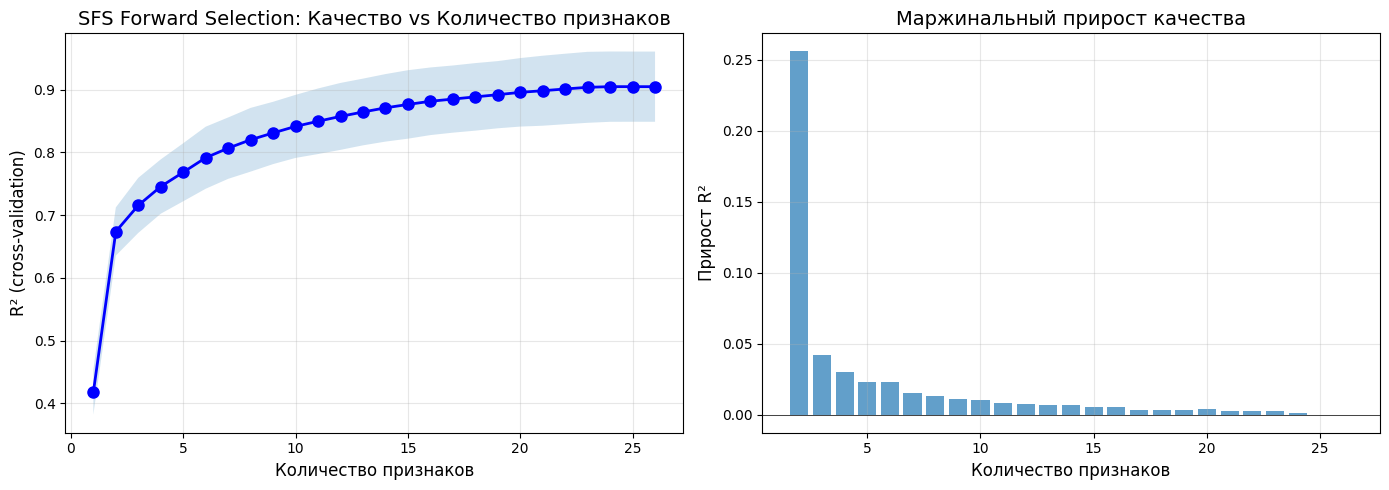

Максимальный прирост качества: 0.2558
Порог для остановки (10% от максимума): 0.0256
Рекомендуемое количество признаков: 4
Качество с 4 признаками: 0.7455
Качество с 27 признаками: 0.9046
Разница: 0.1591


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def analyze_sfs_forward_curve(X_train, y_train):

    max_features = X_train.shape[1]
    
    n_features_range = range(1, max_features)
    scores = []
    std_scores = []
    
    for n in n_features_range:
        sfs = SequentialFeatureSelector(
            estimator=LinearRegression(),
            n_features_to_select=n,
            direction='forward',
            cv=5,
            scoring='r2',
            n_jobs=-1
        )
  
        sfs.fit(X_train, y_train)
     
        X_selected = sfs.transform(X_train)
 
        cv_scores = cross_val_score(LinearRegression(), X_selected, y_train, 
                                   cv=5, scoring='r2')
        scores.append(cv_scores.mean())
        std_scores.append(cv_scores.std())
    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    

    ax1.plot(n_features_range, scores, 'bo-', linewidth=2, markersize=8)
    ax1.fill_between(n_features_range, 
                     np.array(scores) - np.array(std_scores),
                     np.array(scores) + np.array(std_scores),
                     alpha=0.2)
    ax1.set_xlabel('Количество признаков', fontsize=12)
    ax1.set_ylabel('R² (cross-validation)', fontsize=12)
    ax1.set_title('SFS Forward Selection: Качество vs Количество признаков', fontsize=14)
    ax1.grid(True, alpha=0.3)

    improvements = np.diff(scores)
    ax2.bar(n_features_range[1:], improvements, width=0.8, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Количество признаков', fontsize=12)
    ax2.set_ylabel('Прирост R²', fontsize=12)
    ax2.set_title('Маржинальный прирост качества', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Ищем точку, где прирост становится меньше 10% от максимального
    max_improvement = max(improvements)
    threshold = max_improvement * 0.1  
    
    optimal_n = None
    for i, imp in enumerate(improvements):
        if imp < threshold:
            optimal_n = n_features_range[i]
            break
    
    if optimal_n is None:
        optimal_n = max_features
    
    print(f"Максимальный прирост качества: {max_improvement:.4f}")
    print(f"Порог для остановки (10% от максимума): {threshold:.4f}")
    print(f"Рекомендуемое количество признаков: {optimal_n}")
    print(f"Качество с {optimal_n} признаками: {scores[optimal_n-1]:.4f}")
    print(f"Качество с {max_features} признаками: {scores[-1]:.4f}")
    print(f"Разница: {scores[-1] - scores[optimal_n-1]:.4f}")
    
    return optimal_n, scores, n_features_range

optimal_n_sfs, scores, n_range = analyze_sfs_forward_curve(X_train_encoded, y_train)

Здесь, как будто бы слишком мало признаков, поэтому рассмотрим еще одну модель.

+ с использованием любой другой процедуры по желанию (будем использовать встроенную функию `SelectFromModel` с `Lasso`)

Количество выбранных признаков: 10
Выбранные признаки: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes']
R² с отобранными признаками: 0.8386 (+/- 0.0526)


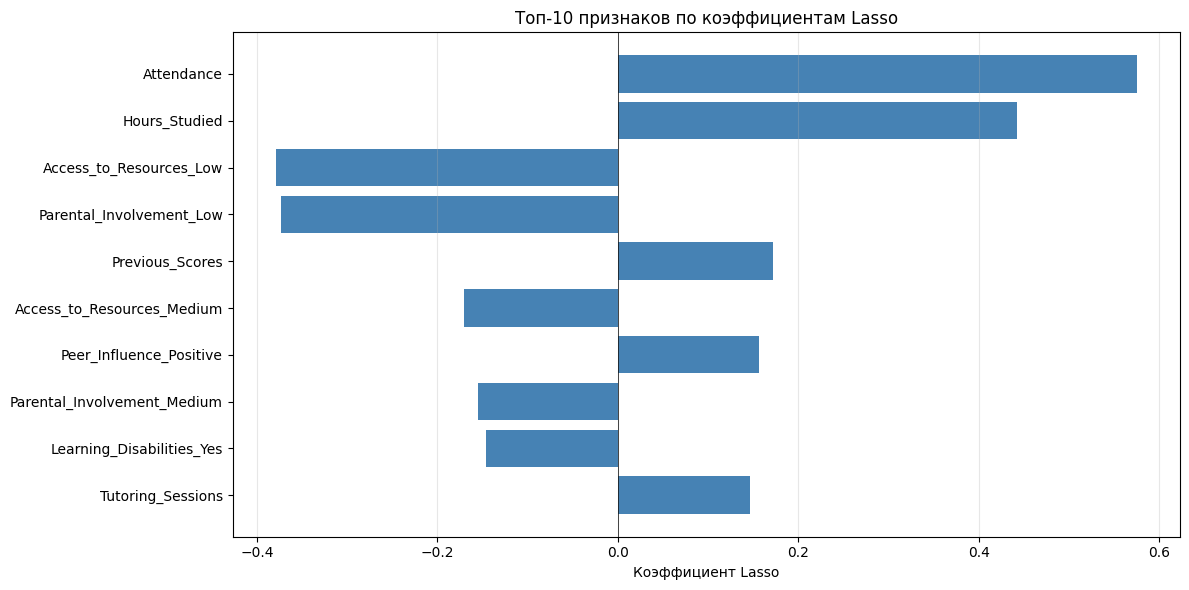

In [41]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

lasso = Lasso(alpha=0.01, random_state=42)
selector_lasso = SelectFromModel(lasso, threshold='mean')

selector_lasso.fit(X_train_encoded, y_train)

selected_mask = selector_lasso.get_support()
selected_features = X_train_encoded.columns[selected_mask].tolist()
n_selected = len(selected_features)

print(f"Количество выбранных признаков: {n_selected}")
print(f"Выбранные признаки: {selected_features}")

X_train_selected = selector_lasso.transform(X_train_encoded)
cv_scores = cross_val_score(LinearRegression(), X_train_selected, y_train, cv=5, scoring='r2')
print(f"R² с отобранными признаками: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

plt.figure(figsize=(12, 6))
coefs = lasso.fit(X_train_encoded, y_train).coef_
indices = np.argsort(np.abs(coefs))[-n_selected:] 

plt.barh(range(len(indices)), coefs[indices], color='steelblue')
plt.yticks(range(len(indices)), X_train_encoded.columns[indices])
plt.xlabel('Коэффициент Lasso')
plt.title('Топ-10 признаков по коэффициентам Lasso')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Здесь количество признаков и величина R**2 достаточно хороши, поэтому переобучим модели на этом количестве признаков.

RFE (Recursive Feature Elimination)
Количество признаков: 10
R²: 0.8110

SFS (Sequential Feature Selector - Forward)
Количество признаков: 10
R²: 0.8414

Lasso
Количество признаков: 10
R²: 0.8386



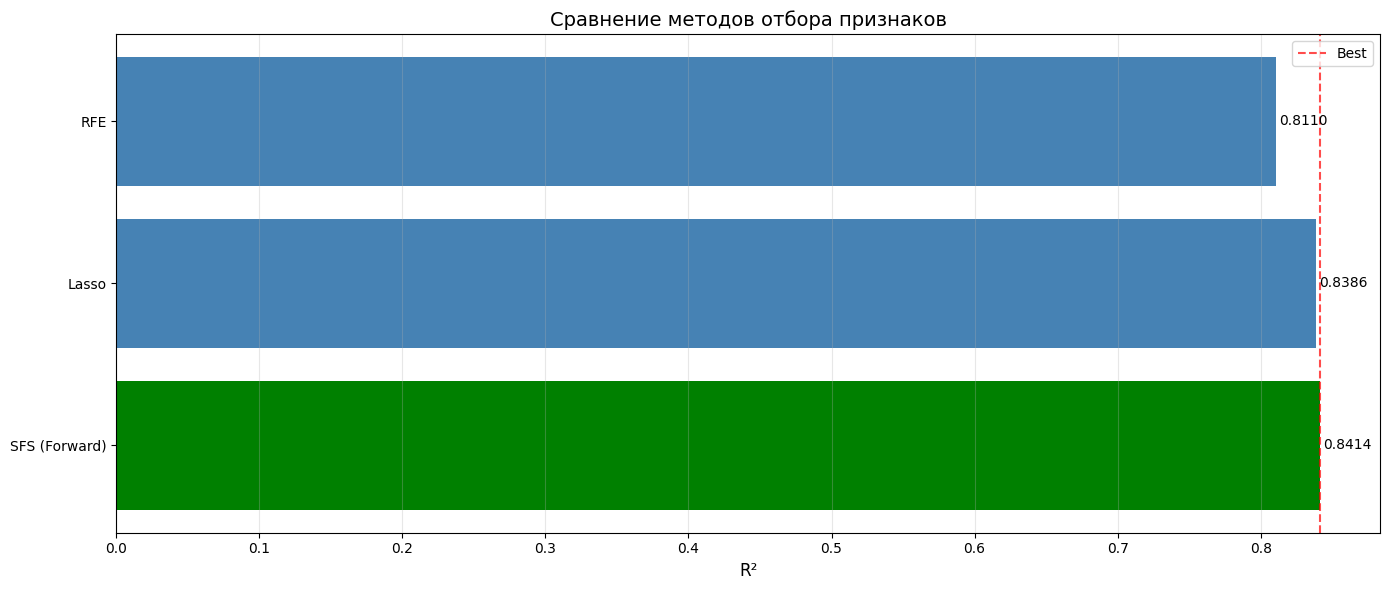

Лучшая процедура фильтрации: SFS (Forward)
   R² Score: 0.8414
   Количество признаков: 10


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, SequentialFeatureSelector, SelectFromModel
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import cross_val_score

results = {}
importance_dict = {}  

print("RFE (Recursive Feature Elimination)")
rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_selected)
rfe.fit(X_train_encoded, y_train)
X_train_rfe = rfe.transform(X_train_encoded)
cv_scores_rfe = cross_val_score(LinearRegression(), X_train_rfe, y_train, cv=5, scoring='r2')

# коэффициенты важности для RFE (на основе рангов)
rfe_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': 1 / (rfe.ranking_ + 1e-10),  # Обратный ранг
    'ranking': rfe.ranking_,
    'selected': rfe.support_
}).sort_values('importance', ascending=False)

results['RFE'] = {
    'n_features': n_selected,
    'R2_score': cv_scores_rfe.mean(),
    'R2_std': cv_scores_rfe.std(),
    'selected_features': X_train_encoded.columns[rfe.support_].tolist(),
    'importance': rfe_importance
}
importance_dict['RFE'] = rfe_importance
print(f"Количество признаков: {results['RFE']['n_features']}")
print(f"R²: {results['RFE']['R2_score']:.4f}\n")

print("SFS (Sequential Feature Selector - Forward)")
sfs = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select=n_selected,
    direction='forward',
    cv=5,
    scoring='r2',
    n_jobs=-1
)
sfs.fit(X_train_encoded, y_train)
X_train_sfs = sfs.transform(X_train_encoded)
cv_scores_sfs = cross_val_score(LinearRegression(), X_train_sfs, y_train, cv=5, scoring='r2')

sfs_model = LinearRegression()
sfs_model.fit(X_train_sfs, y_train)


sfs_importance = pd.DataFrame({
    'feature': X_train_encoded.columns[sfs.get_support()],  
    'importance': np.abs(sfs_model.coef_)
}).sort_values('importance', ascending=False)

results['SFS (Forward)'] = {
    'n_features': n_selected,
    'R2_score': cv_scores_sfs.mean(),
    'R2_std': cv_scores_sfs.std(),
    'selected_features': X_train_encoded.columns[sfs.get_support()].tolist(),
    'importance': sfs_importance
}
importance_dict['SFS (Forward)'] = sfs_importance
print(f"Количество признаков: {results['SFS (Forward)']['n_features']}")
print(f"R²: {results['SFS (Forward)']['R2_score']:.4f}\n")

print("Lasso")
lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train_encoded, y_train)

lasso_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': np.abs(lasso_model.coef_)
}).sort_values('importance', ascending=False)

top_features = lasso_importance.head(n_selected)['feature'].tolist()
X_train_selected = X_train_encoded[top_features]
cv_scores_lasso = cross_val_score(LinearRegression(), X_train_selected, y_train, cv=5, scoring='r2')

results['Lasso'] = {
    'n_features': n_selected,
    'R2_score': cv_scores_lasso.mean(),
    'R2_std': cv_scores_lasso.std(),
    'selected_features': top_features,
    'importance': lasso_importance.head(n_selected) 
}
importance_dict['Lasso'] = lasso_importance.head(n_selected)
print(f"Количество признаков: {results['Lasso']['n_features']}")
print(f"R²: {results['Lasso']['R2_score']:.4f}\n")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2_score', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['green' if i==0 else 'steelblue' for i in range(len(results_df))]
ax.barh(results_df.index, results_df['R2_score'], color=colors)
ax.set_xlabel('R²', fontsize=12)
ax.set_title('Сравнение методов отбора признаков', fontsize=14)
ax.axvline(x=results_df['R2_score'].max(), color='red', linestyle='--', alpha=0.7, label='Best')
ax.grid(axis='x', alpha=0.3)
ax.legend()

for i, v in enumerate(results_df['R2_score']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

best_method = results_df.index[0]
best_score = results_df.iloc[0]['R2_score']
best_features = results_df.iloc[0]['selected_features']
best_importance = importance_dict[best_method]

print(f"Лучшая процедура фильтрации: {best_method}")
print(f"   R² Score: {best_score:.4f}")
print(f"   Количество признаков: {len(best_features)}")

Выбрать лучшую процедуру фильтрации. 

В качестве модели-оценщика была использована модель `LinearRegression`, лучшая процедура на заданном наборе признаков `SFS` позволила сократить размерность на более чем 60%, сохраняя высокую метрику R**2.

Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).

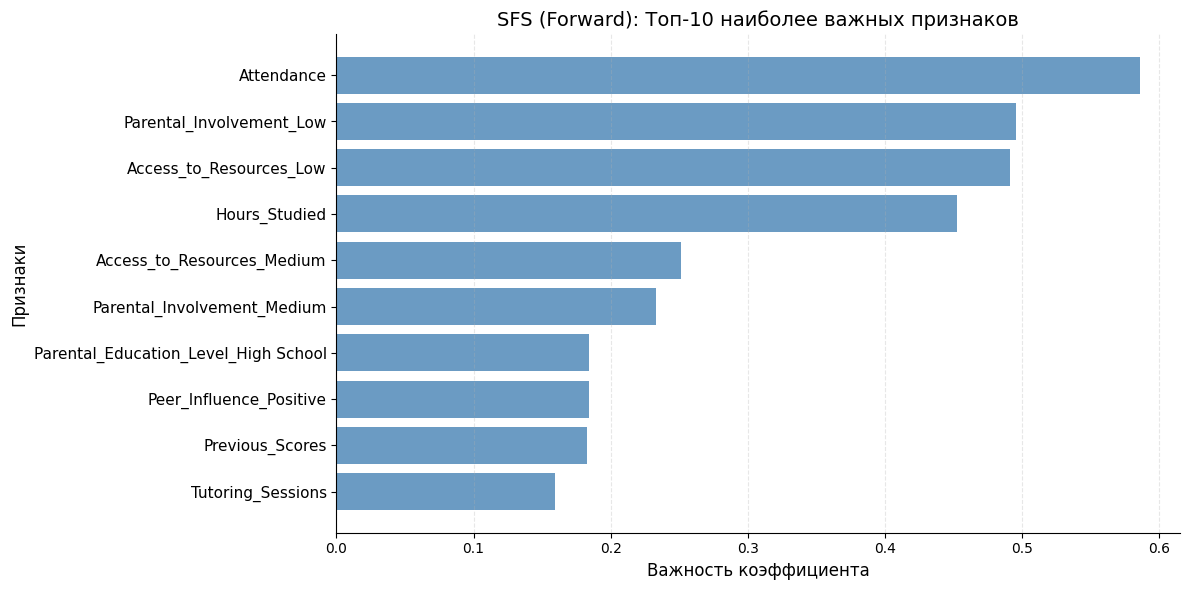

In [43]:
top_n = min(15, len(best_importance))
top_features_imp = best_importance.head(top_n).copy()
top_features_imp = top_features_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, top_n * 0.4)))

bars = ax.barh(range(len(top_features_imp)), top_features_imp['importance'].values, 
                color='steelblue', alpha=0.8)


ax.set_yticks(range(len(top_features_imp)))
ax.set_yticklabels(top_features_imp['feature'].values, fontsize=11)
ax.set_xlabel('Важность коэффициента', fontsize=12)
ax.set_ylabel('Признаки', fontsize=12)
ax.set_title(f'{best_method}: Топ-{top_n} наиболее важных признаков', fontsize=14)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Вывести значения метрик на тестовом наборе ($MSE$, $MAE$ и $R^2$).

In [44]:
top_features_imp['feature'].values

array(['Tutoring_Sessions', 'Previous_Scores', 'Peer_Influence_Positive',
       'Parental_Education_Level_High School',
       'Parental_Involvement_Medium', 'Access_to_Resources_Medium',
       'Hours_Studied', 'Access_to_Resources_Low',
       'Parental_Involvement_Low', 'Attendance'], dtype=object)

In [45]:
model = best_models_encoded['Ridge'][0]

model.fit(X_train_encoded[top_features_imp['feature'].values], y_train)
y_pred = model.predict(X_test_encoded[top_features_imp['feature'].values]) 

metrics = evaluate_model(y_test, y_pred)

MSE: 0.13, MAE: 0.21, R²: 0.84 



 ### 7. Сделать вывод:


   - Лучший регрессор, обученный на данных без категориальных признаков (значения метрик на тестовом наборе).


In [46]:
model = best_models_encoded['Ridge'][0]

model.fit(X_train_quantitative, y_train)
y_pred = model.predict(X_test_quantitative) 

metrics = evaluate_model(y_test, y_pred)

MSE: 0.20, MAE: 0.30, R²: 0.75 



   - Лучший регрессор, обученный на данных с категориальными признаками (значения метрик на тестовом наборе).

In [47]:
model = best_models_encoded['Ridge'][0]

model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded) 

metrics = evaluate_model(y_test, y_pred)

MSE: 0.07, MAE: 0.08, R²: 0.91 



С добавлением категориальных признаков метрики для `MSE`, `MAE` для моделей класса линейныйх регрессий снизились минимум вдвое (наилучшее изменение - практически в 3 раза). Показатель метрики для `R**2` наоборот увеличился, тем самым отразив качество модели (целевое значение для этой метрики 1, а наилучшее найденное значение ~ 0.91).

   - Вывод о результатах использования процедуры фильтрации признаков (лучше или хуже &ndash; значения метрик).

In [48]:
model = best_models_encoded['Ridge'][0]

model.fit(X_train_encoded[top_features_imp['feature'].values], y_train)
y_pred = model.predict(X_test_encoded[top_features_imp['feature'].values]) 

metrics = evaluate_model(y_test, y_pred)

MSE: 0.13, MAE: 0.21, R²: 0.84 



Применение лучшей модели для отфильтрованных признаков привело к ухудшению результатов для всех метрик. Это может быть связано с тем, когда некоторые признаки удаляются в Ridge регрессоре, то модель штрафуется дважды, что может привести к недообучению (метрика R**2 сократилась практически на 10%).

Однако этот результат лучше метрик, полученных на только количественных данных. Это подтверждает гипотезу, что данных не достаточно для качественного обучения.